# 08 — K-Means Style Discovery

**Goal:** Compare K-Means clustering at k=4, 5, 6; select optimal k via elbow/silhouette; interpret cluster centroids as style prototypes (e.g. “Striker”, “Grappler”, “Mixed”). Produces the first data-driven fighting style taxonomy.

**Input:** `ufc_modeling_data_final.csv`, `ufc_fight_stats_cleaned.csv`

**Methodology:** For each k: (1) fit K-Means, (2) visualize cluster centroids, (3) project into 2D (PCA), (4) examine fighter examples, (5) compute silhouette score.

**Takeaway:** Cluster centroids are the “average fighter” in each group—interpret them as archetypes. The PCA loadings table shows what each axis represents (e.g. PC1 = striking vs grappling). Silhouette score measures how well-separated clusters are; higher is better.


In [5]:
# --- Core pipeline load for this notebook ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Load Data
df = pd.read_csv('../data/processed/ufc_modeling_data_final.csv')
fights = pd.read_csv('../data/processed/ufc_fight_stats_cleaned.csv')

# Add Total_Fights safely to prevent column collisions
fight_counts = fights['Fighter'].value_counts().rename('Total_Fights')
if 'Total_Fights' in df.columns:
    df = df.drop(columns=['Total_Fights'])
df = df.join(fight_counts, on='Fighter')
df['Total_Fights'] = df['Total_Fights'].fillna(0)

# Feature Selection
features = [
    'Sig_Str_PM_Z',       # Striking Volume
    'Takedown_Att_PM_Z',  # Wrestling Aggression
    'Sub_Att_PM_Z',       # Grappling Threat
    'Control_Ratio_Z',    # Control Dominance
    'Distance_Ratio',     # Positional Preference
    'Clinch_Ratio',
    'Ground_Ratio'
]

# Prepare X (Drop NaNs)
X = df[features].dropna()
print(f"Data ready for clustering: {X.shape[0]} fighters.")

# Standardize (Important for distance-based algorithms)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Data ready for clustering: 1190 fighters.


## Automated Comparison Loop
We loop through $k=4, 5, 6$ and generate all diagnostics automatically.

## PCA Component Loadings (mathematical weights)
Run the cell below to see the **loadings table**: each row is a feature, each column is a principal component (PC1, PC2), and each value is the **weight** (loading) — how much that feature contributes to that component.

In [6]:
# Fit PCA once for interpretation and reuse in loop
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Component loadings: weight of each feature for each PC (rows=features, columns=PCs)
loadings = pd.DataFrame(pca.components_.T, index=features, columns=['PC1', 'PC2'])
print("PCA Component Loadings (weight of each feature per component):")
print("  Rows = features | Columns = PC1, PC2 | Value = loading (contribution)")
try:
    from IPython.display import display
    display(loadings.round(3))
except ImportError:
    print(loadings.round(3).to_string())
print(f"\nVariance explained: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")
pc1_top = loadings['PC1'].abs().nlargest(3)
pc2_top = loadings['PC2'].abs().nlargest(3)
print("\nInterpretation (fight context):")
print(f"  PC1: Dominated by {list(pc1_top.index)} — main style axis (e.g. striker vs grappler)")
print(f"  PC2: Dominated by {list(pc2_top.index)} — secondary axis (e.g. positional preference)")


PCA Component Loadings (weight of each feature per component):
  Rows = features | Columns = PC1, PC2 | Value = loading (contribution)


,PC1,PC2
Sig_Str_PM_Z,-0.279,-0.131
Takedown_Att_PM_Z,0.400,0.296
Sub_Att_PM_Z,0.259,0.332
Control_Ratio_Z,0.470,0.201
Distance_Ratio,-0.470,0.396
Clinch_Ratio,0.223,-0.765
Ground_Ratio,0.451,0.048



Variance explained: PC1=47.3%, PC2=16.9%

Interpretation (fight context):
  PC1: Dominated by ['Distance_Ratio', 'Control_Ratio_Z', 'Ground_Ratio'] — main style axis (e.g. striker vs grappler)
  PC2: Dominated by ['Clinch_Ratio', 'Distance_Ratio', 'Sub_Att_PM_Z'] — secondary axis (e.g. positional preference)



Running K-Means for k=4
Silhouette Score: 0.227


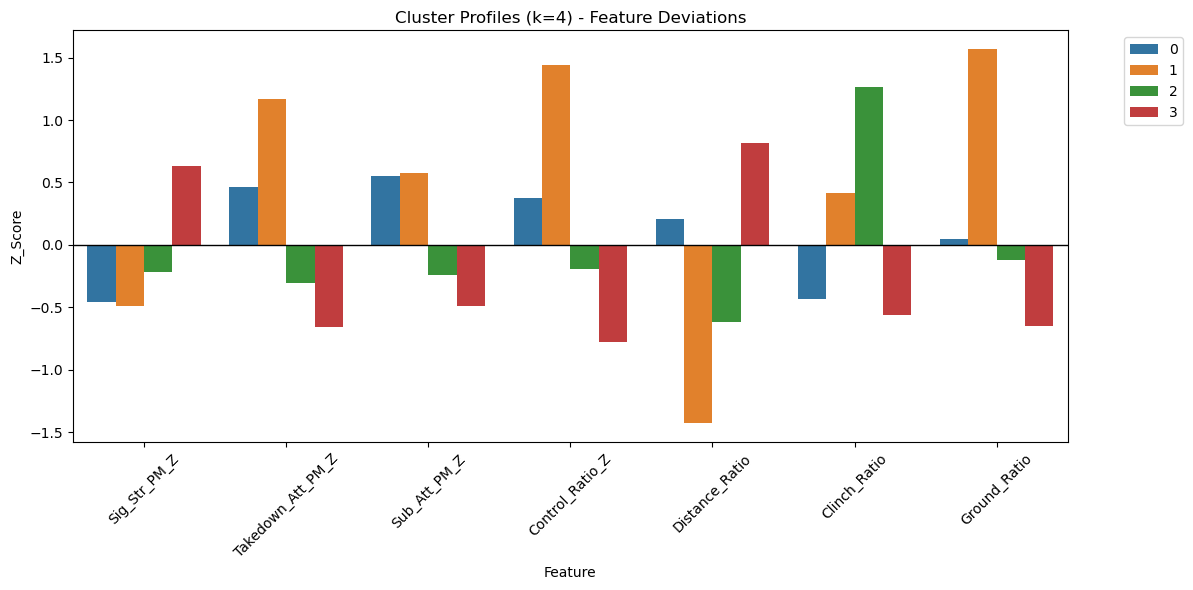

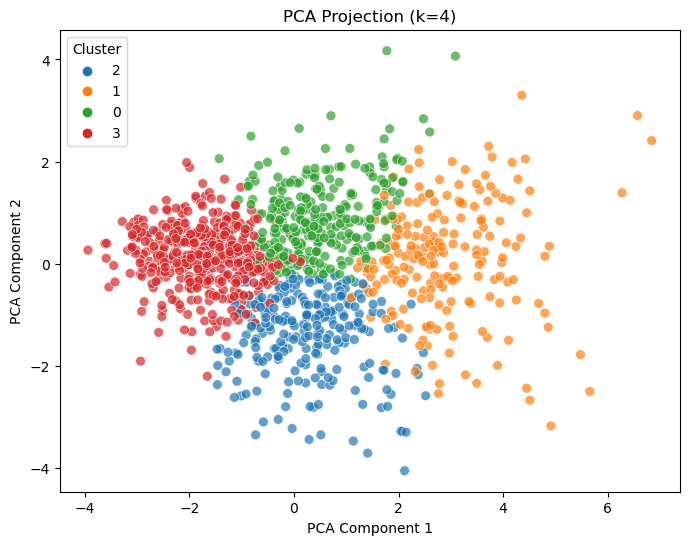


Cluster Examples (k=4):
  Cluster 0 (Most Fights): ['Jim Miller' 'Charles Oliveira' 'Rafael Dos Anjos' 'Jeremy Stephens'
 'Diego Sanchez' 'Frankie Edgar' 'Ovince Saint Preux' 'Gerald Meerschaert']
  Cluster 1 (Most Fights): ['Clay Guida' 'Demian Maia' 'Darren Elkins' 'Gleison Tibau' 'Joe Lauzon'
 'Frank Mir' 'Tito Ortiz' 'Matt Hughes']
  Cluster 2 (Most Fights): ['Neil Magny' 'Matt Brown' 'Derrick Lewis' 'Nate Diaz' 'BJ Penn'
 'Francisco Trinaldo' 'Vitor Belfort' 'Ed Herman']
  Cluster 3 (Most Fights): ['Andrei Arlovski' 'Donald Cerrone' 'Dustin Poirier' 'Edson Barboza'
 'Michael Johnson' 'Max Holloway' 'Alex Caceres' 'Tim Means']

Running K-Means for k=5
Silhouette Score: 0.218


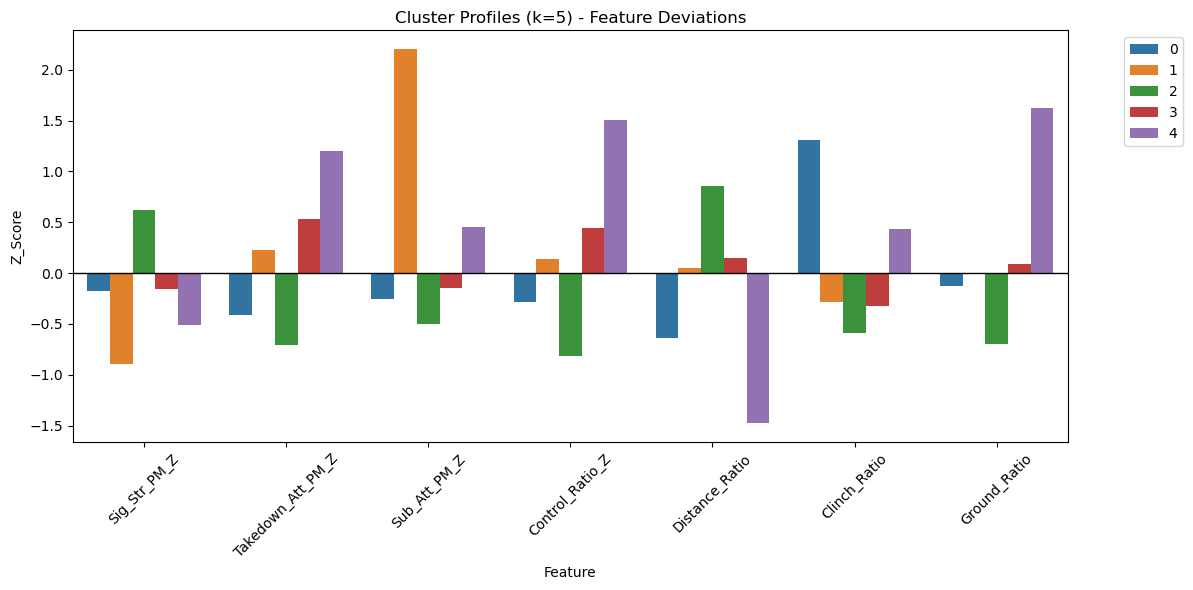

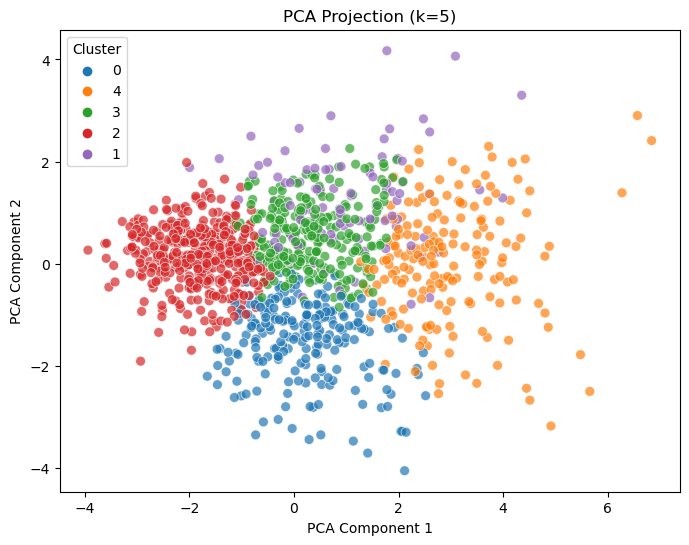


Cluster Examples (k=5):
  Cluster 0 (Most Fights): ['Derrick Lewis' 'Matt Brown' 'Nate Diaz' 'BJ Penn' 'Ed Herman'
 'Francisco Trinaldo' 'Vitor Belfort' 'Anderson Silva']
  Cluster 1 (Most Fights): ['Jim Miller' 'Charles Oliveira' 'Frank Mir' 'Stefan Struve' 'Paul Craig'
 'Rani Yahya' 'Deiveson Figueiredo' 'Chris Lytle']
  Cluster 2 (Most Fights): ['Andrei Arlovski' 'Donald Cerrone' 'Edson Barboza' 'Dustin Poirier'
 'Michael Johnson' 'Max Holloway' 'Alex Caceres' 'Jessica Andrade']
  Cluster 3 (Most Fights): ['Clay Guida' 'Rafael Dos Anjos' 'Neil Magny' 'Jeremy Stephens'
 'Diego Sanchez' 'Frankie Edgar' 'Ovince Saint Preux' 'Gerald Meerschaert']
  Cluster 4 (Most Fights): ['Demian Maia' 'Darren Elkins' 'Gleison Tibau' 'Joe Lauzon' 'Tito Ortiz'
 'Josh Koscheck' 'Nik Lentz' 'Matt Hughes']

Running K-Means for k=6
Silhouette Score: 0.173


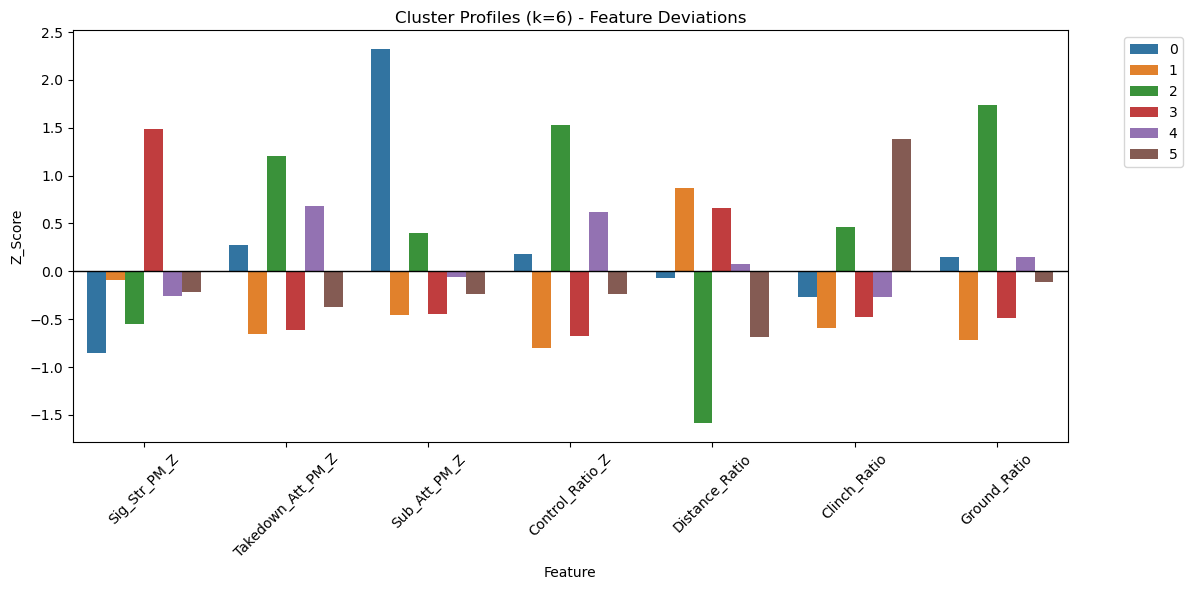

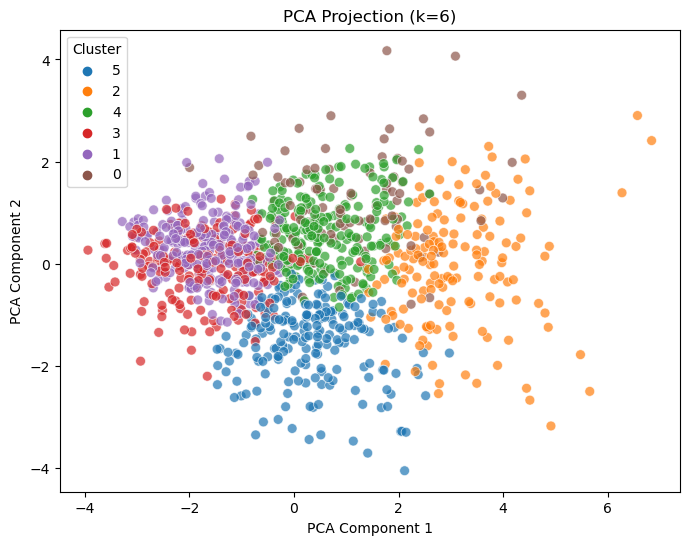


Cluster Examples (k=6):
  Cluster 0 (Most Fights): ['Jim Miller' 'Charles Oliveira' 'Frank Mir' 'Stefan Struve' 'Paul Craig'
 'Rani Yahya' 'Chris Lytle' 'Deiveson Figueiredo']
  Cluster 1 (Most Fights): ['Andrei Arlovski' 'Donald Cerrone' 'Jeremy Stephens' 'Edson Barboza'
 'Michael Johnson' 'Alex Caceres' 'Thiago Alves' 'Brad Tavares']
  Cluster 2 (Most Fights): ['Demian Maia' 'Joe Lauzon' 'Tito Ortiz' 'Matt Hughes' 'Josh Koscheck'
 'Randy Couture' 'Glover Teixeira' 'Georges St-Pierre']
  Cluster 3 (Most Fights): ['Dustin Poirier' 'Max Holloway' 'Tim Means' 'Jessica Andrade'
 'Michael Bisping' 'Angela Hill' 'Kevin Holland' 'King Green']
  Cluster 4 (Most Fights): ['Clay Guida' 'Neil Magny' 'Rafael Dos Anjos' 'Diego Sanchez'
 'Frankie Edgar' 'Darren Elkins' 'Ovince Saint Preux' 'Gleison Tibau']
  Cluster 5 (Most Fights): ['Derrick Lewis' 'Matt Brown' 'BJ Penn' 'Nate Diaz' 'Vitor Belfort'
 'Ed Herman' 'Francisco Trinaldo' 'Robbie Lawler']


In [7]:
k_values = [4, 5, 6]
silhouette_scores = []

for k in k_values:
    print(f"\n{'='*40}\nRunning K-Means for k={k}\n{'='*40}")
    
    # 1. Fit Model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)
    
    # Calculate Score
    score = silhouette_score(X_scaled, clusters)
    silhouette_scores.append(score)
    print(f"Silhouette Score: {score:.3f}")
    
    # 2. Visualize Centroids (The "DNA" of the clusters)
    centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=features)
    centroids_scaled = pd.DataFrame(kmeans.cluster_centers_, columns=features)
    centroids_scaled['Cluster'] = [str(c) for c in range(k)]
    centroids_melt = centroids_scaled.melt(id_vars='Cluster', var_name='Feature', value_name='Z_Score')
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Feature', y='Z_Score', hue='Cluster', data=centroids_melt, palette='tab10')
    plt.title(f'Cluster Profiles (k={k}) - Feature Deviations')
    plt.axhline(0, color='black', linewidth=1)
    plt.xticks(rotation=45)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    
    # 3. PCA Projection (2D for visualization — X_pca from cell above)
    clusters_str = [str(c) for c in clusters]

    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters_str, palette='tab10', alpha=0.7, s=50)
    plt.title(f'PCA Projection (k={k})')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.legend(title='Cluster')
    plt.show()
    
    # 4. Show Examples
    temp_df = df.loc[X.index].copy()
    temp_df['Cluster'] = clusters
    
    print(f"\nCluster Examples (k={k}):")
    for c in range(k):
        examples = temp_df[temp_df['Cluster'] == c].sort_values('Total_Fights', ascending=False)['Fighter'].head(8).values
        print(f"  Cluster {c} (Most Fights): {examples}")


## Conclusion & Recommendation
We compare the Silhouette Scores to see which $k$ fits the data "best" mathematically, but we also rely on domain knowledge to pick the most interpretable model.

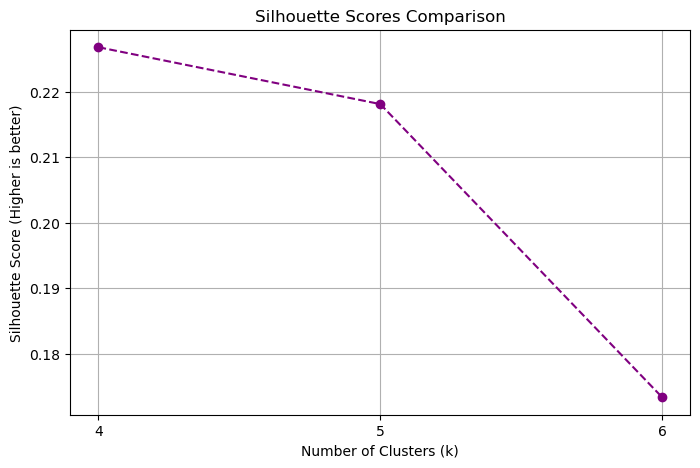

Mathematically best k: 4 (Score: 0.227)


In [8]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='--', color='purple')
plt.title('Silhouette Scores Comparison')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score (Higher is better)')
plt.xticks(k_values)
plt.grid(True)
plt.show()

best_k = k_values[np.argmax(silhouette_scores)]
print(f"Mathematically best k: {best_k} (Score: {max(silhouette_scores):.3f})")


**Interpretation of silhouette plot:** The k with the highest silhouette score has the most distinct, well-separated clusters. A “knee” or plateau suggests diminishing returns from adding more clusters. Use this alongside interpretability: if k=5 yields clear “Striker/Grappler/Mixed” labels but k=6 does not, prefer k=5 for downstream analysis.

### Stars in K-Means clusters (`ufc_clusters_baseline.csv`)
**Interpretation:** Compare to your centroid labels—known strikers vs wrestlers should map sensibly.


In [ ]:
import pandas as pd
stars = ['Jon Jones', 'Israel Adesanya', 'Khabib Nurmagomedov', 'Conor McGregor', 'Georges St-Pierre', 'Amanda Nunes', 'Anderson Silva', 'Max Holloway', 'Stipe Miocic']
km = pd.read_csv('../data/processed/ufc_clusters_baseline.csv')
z = [c for c in km.columns if c.endswith('_Z')][:4]
sub = km[km['Fighter'].isin(stars)][['Fighter','Cluster'] + z]
print(sub.to_string(index=False))
